📊 Exploratory Data Analysis (EDA) on Retail Sales Data
 Oasis Infobyte Data Analytics Internship

Level: 1
Task: EDA on Retail Sales Data
Author: Moubani

📌Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on a retail sales dataset to uncover
customer purchasing patterns,sales trends, and business insights through statistical analysis and data visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✅ Libraries loaded successfully!")

✅ Libraries loaded successfully!


In [ ]:
df = pd.read_csv('Retail_Sales.csv')
df.rename(columns={'quantiy': 'quantity'}, inplace=True)

print("========== DATASET SHAPE ==========")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n========== DATASET INFORMATION ==========")
df.info()

print("\n========== COLUMN DATA TYPES ==========")
print(df.dtypes)

print("\n========== NULL VALUE CHECK ==========")
print(df.isnull().sum())

print("\n========== DUPLICATE RECORDS ==========")
print(df.duplicated().sum())


df_clean = df.dropna().copy()
print("\n========== CLEANED DATASET ==========")
print(f"Rows after removing missing values: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")

========== DATASET SHAPE ==========
Rows: 2000
Columns: 11

========== DATASET INFORMATION ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transactions_id  2000 non-null   int64  
 1   sale_date        2000 non-null   object 
 2   sale_time        2000 non-null   object 
 3   customer_id      2000 non-null   int64  
 4   gender           2000 non-null   object 
 5   age              1990 non-null   float64
 6   category         2000 non-null   object 
 7   quantity         1997 non-null   float64
 8   price_per_unit   1997 non-null   float64
 9   cogs             1997 non-null   float64
 10  total_sale       1997 non-null   float64
dtypes: float64(5), int64(2), object(4)
memory usage: 172.0+ KB

========== COLUMN DATA TYPES ==========
transactions_id      int64
sale_date           object
sale_time           object
custome

 📖 Observation

- The dataset contains 2,000 transactions with 11 columns.
- Data types include numerical, categorical, and date fields.
- A small number of missing values were found in Age, Quantity, Price Per Unit, COGS, and Total Sale.
- No duplicate records were detected.
- After removing missing values, 1,987 records remained for analysis.

In [ ]:
num_cols = ['age', 'quantity', 'price_per_unit', 'cogs', 'total_sale']

stats_df = pd.DataFrame({
    'Mean': df_clean[num_cols].mean(),
    'Median': df_clean[num_cols].median(),
    'Mode': df_clean[num_cols].mode().iloc[0],
    'Standard Deviation': df_clean[num_cols].std()
})

print("========== DESCRIPTIVE STATISTICS ==========")
display(stats_df)

========== DESCRIPTIVE STATISTICS ==========


,Mean,Median,Mode,Standard Deviation
age,41.351283,42.0,43.0,13.662653
quantity,2.513840,3.0,4.0,1.132770
price_per_unit,179.924509,50.0,50.0,189.441178
cogs,95.081933,27.5,13.5,122.032280
total_sale,457.086059,150.0,50.0,560.862242


## 📖 Observation

- The average customer age is approximately 41 years.
- The average transaction value is around $456, while the median transaction value is much lower.
- This difference between mean and median suggests the presence of several high-value purchases that increase the overall average.

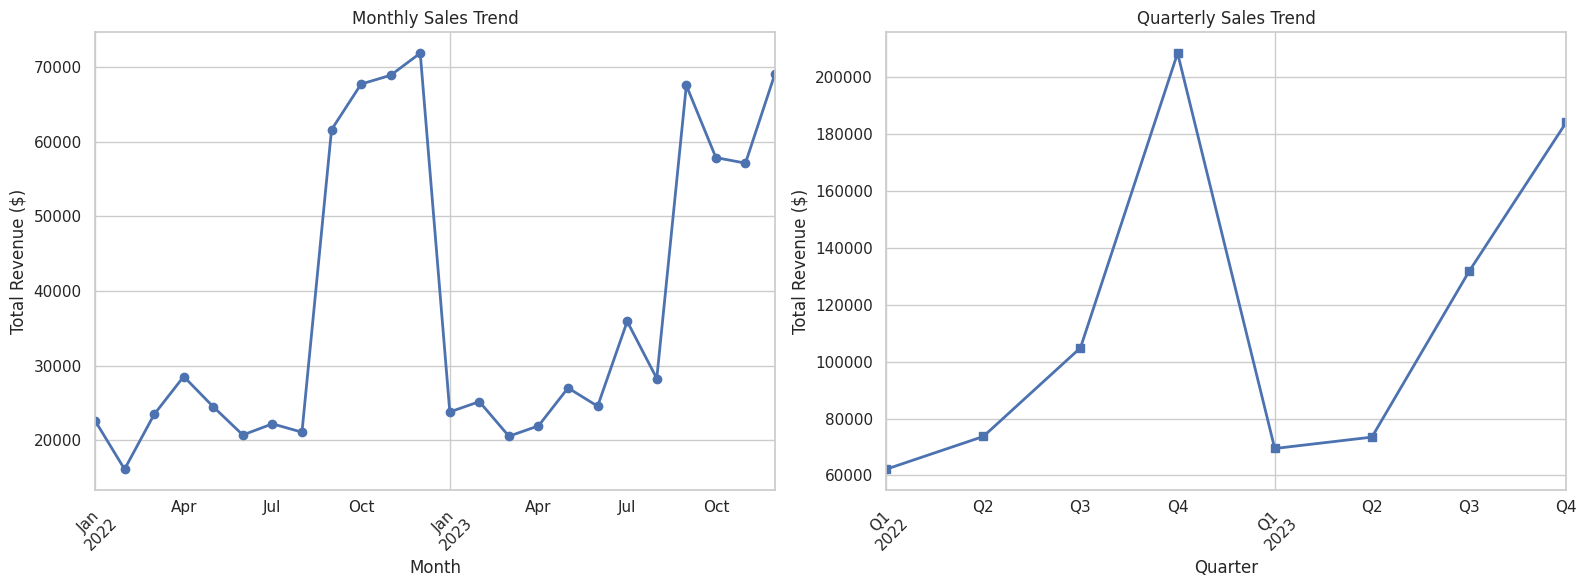

In [ ]:
df_clean['sale_date'] = pd.to_datetime(df_clean['sale_date'])
df_clean['YearMonth'] = df_clean['sale_date'].dt.to_period('M')
df_clean['Quarter'] = df_clean['sale_date'].dt.to_period('Q')

fig, axes = plt.subplots(1, 2, figsize=(16,6))

monthly_sales = df_clean.groupby('YearMonth')['total_sale'].sum()
monthly_sales.plot(
    kind='line',
    marker='o',
    linewidth=2,
    ax=axes[0]
)

axes[0].set_title("Monthly Sales Trend")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total Revenue ($)")
axes[0].tick_params(axis='x', rotation=45)

quarterly_sales = df_clean.groupby('Quarter')['total_sale'].sum()
quarterly_sales.plot(
    kind='line',
    marker='s',
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title("Quarterly Sales Trend")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Total Revenue ($)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("monthly_quarterly_sales.png", dpi=300)
plt.show()

## 📖 Observation

- Sales fluctuate throughout the year but increase significantly during the final quarter (Q4).
- October to December consistently generate the highest revenue, indicating strong seasonal demand.
- Businesses should prepare inventory and marketing campaigns ahead of these peak months.

/tmp/ipykernel_3055/3297930910.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


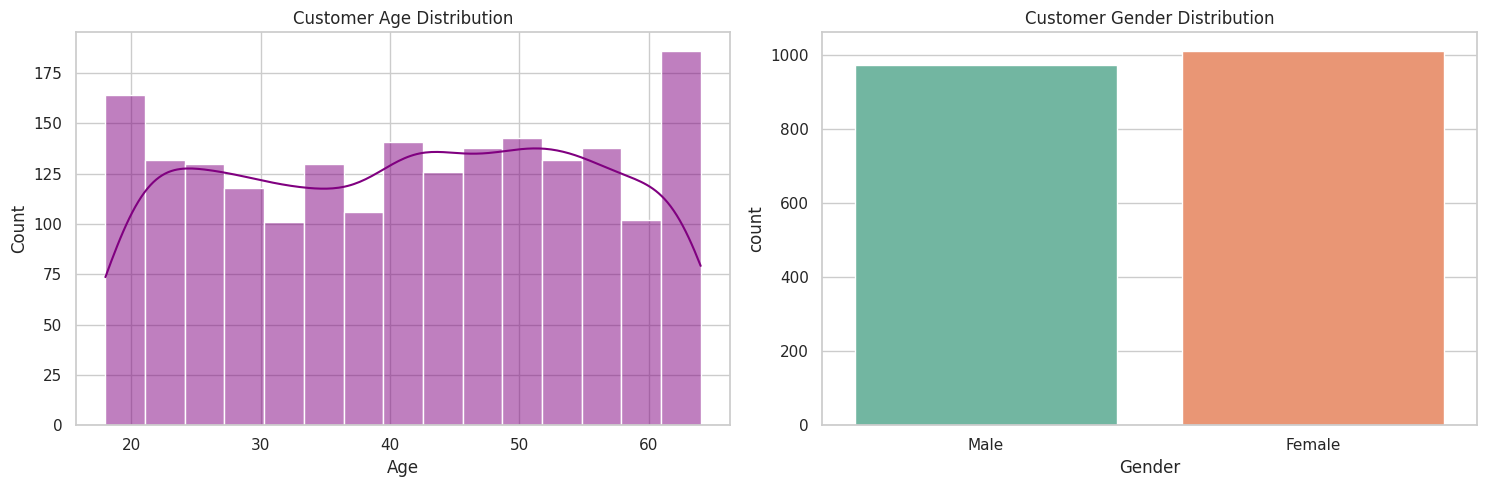

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(15,5))

sns.histplot(
    data=df_clean,
    x='age',
    bins=15,
    kde=True,
    color='purple',
    ax=axes[0]
)

axes[0].set_title("Customer Age Distribution")
axes[0].set_xlabel("Age")

sns.countplot(
    data=df_clean,
    x='gender',
    palette='Set2',
    ax=axes[1]
)

axes[1].set_title("Customer Gender Distribution")
axes[1].set_xlabel("Gender")

plt.tight_layout()
plt.savefig("customer_demographics.png", dpi=300)
plt.show()

## 📖 Observation

- Customers are distributed across a wide age range between 18 and 64 years.
- The gender distribution is nearly balanced, indicating that both male and female customers contribute almost equally to sales.

> **Note:** This dataset does not contain individual product names. Therefore, product analysis is performed at the **category** level instead of identifying the top 10 best-selling products.

/tmp/ipykernel_3055/3343002792.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


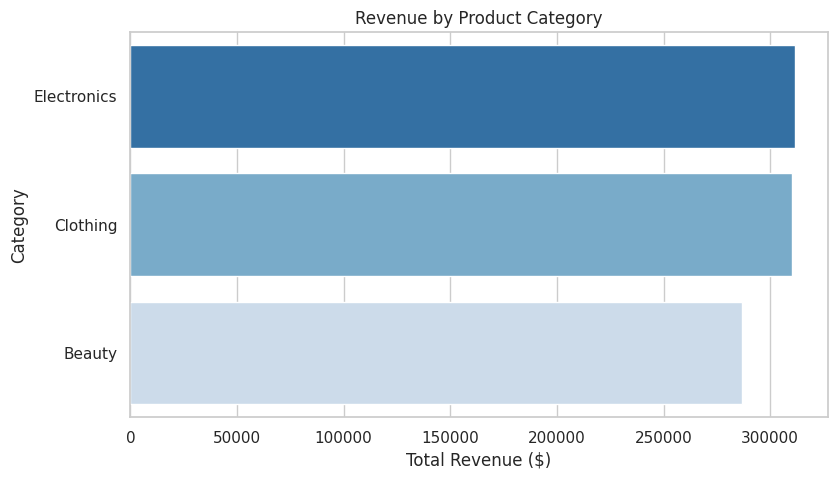

category
Electronics    311445.0
Clothing       309995.0
Beauty         286790.0
Name: total_sale, dtype: float64


In [ ]:
category_revenue = (
    df_clean
    .groupby('category')['total_sale']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,5))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index,
    palette='Blues_r'
)

plt.title("Revenue by Product Category")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Category")
plt.savefig("category_revenue.png", dpi=300)
plt.show()
print(category_revenue)

## 📖 Observation

- Electronics generates the highest revenue, followed closely by Clothing.
- Beauty contributes the lowest revenue among the three categories.
- Increasing promotional activities for Beauty products may help improve overall sales.

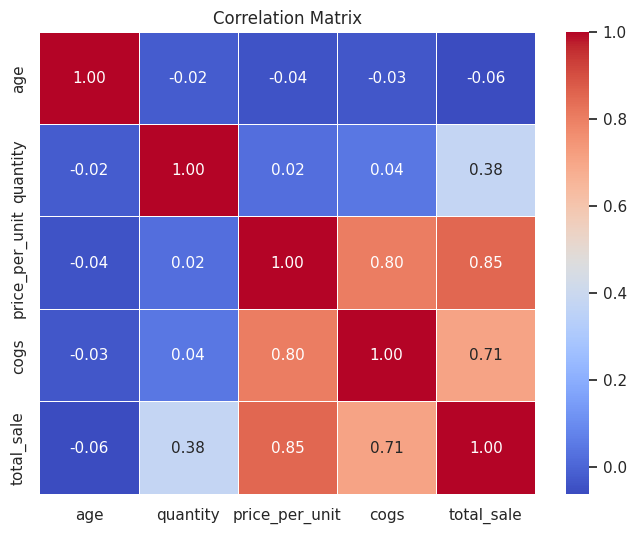

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_clean[num_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.savefig("correlation_heatmap.png", dpi=300)
plt.show()

## 📖 Observation

- Price per unit has a strong positive correlation with total sales.
- Higher-priced products contribute significantly to overall revenue.
- Quantity and COGS also exhibit positive relationships with total sales.

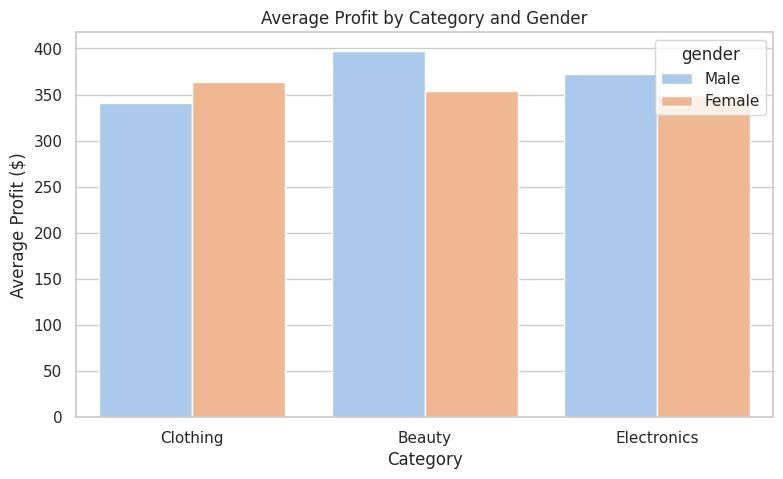

In [ ]:
df_clean['profit'] = df_clean['total_sale'] - df_clean['cogs']
plt.figure(figsize=(9,5))

sns.barplot(
    data=df_clean,
    x='category',
    y='profit',
    hue='gender',
    errorbar=None,
    palette='pastel'
)

plt.title("Average Profit by Category and Gender")
plt.xlabel("Category")
plt.ylabel("Average Profit ($)")
plt.savefig("profit_analysis.png", dpi=300)
plt.show()

## 📖 Observation

- Male customers generate higher average profit in the Electronics and Beauty categories.
- Female customers contribute higher average profit in the Clothing category.
- These differences can guide category-specific marketing strategies.

# 💡 Conclusion & Actionable Business Recommendations

Based on the exploratory data analysis, the following recommendations are suggested:

1. **Prepare for Seasonal Demand:** Increase inventory levels and marketing campaigns before Q4 (October–December), as sales consistently peak during this period.

2. **Category-Specific Marketing:** Focus promotional campaigns for Clothing on female customers while promoting premium Electronics and Beauty products to male customers.

3. **Increase Average Order Value:** Since **price per unit** has a strong positive relationship with total sales, businesses should encourage customers to purchase premium products through bundled offers and personalized recommendations.

4. **Improve Beauty Category Performance:** Although Beauty products contribute substantial revenue, targeted discounts and cross-selling strategies could further enhance sales.

5. **Leverage Customer Insights:** Continue monitoring customer demographics and purchasing behavior to develop more personalized marketing campaigns and improve customer satisfaction.